In [1]:
from pathlib import Path
import os

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


# 固定随机种子
SEED = 42

# 项目目录：network collapse
BASE_DIR = Path.cwd()

# 防止当前目录在 data 或 result 里面
if BASE_DIR.name.lower() in ["data", "result", "sbm", "degree_ccdf"]:
    while BASE_DIR.name.lower() != "network collapse":
        BASE_DIR = BASE_DIR.parent

# 如果从 C:\Users\86185 启动，也自动进入 network collapse
if (BASE_DIR / "network collapse").exists():
    BASE_DIR = BASE_DIR / "network collapse"

os.chdir(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
SBM_DIR = DATA_DIR / "sbm"
RESULT_DIR = BASE_DIR / "result"
CCDF_DIR = RESULT_DIR / "degree_ccdf"

DATA_DIR.mkdir(exist_ok=True)
SBM_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
CCDF_DIR.mkdir(exist_ok=True)

print("当前项目目录：", BASE_DIR)
print("SBM 数据目录：", SBM_DIR)
print("CCDF 结果目录：", CCDF_DIR)
print("NetworkX 版本：", nx.__version__)

当前项目目录： C:\Users\86185\network collapse
SBM 数据目录： C:\Users\86185\network collapse\data\sbm
CCDF 结果目录： C:\Users\86185\network collapse\result\degree_ccdf
NetworkX 版本： 2.6.3


In [2]:
def make_sbm_probability_matrix(num_blocks, pin, pout):
    """
    生成 SBM 概率矩阵：
    对角线是 pin，表示社区内部连边概率；
    非对角线是 pout，表示社区之间连边概率。
    """
    p = np.full((num_blocks, num_blocks), pout, dtype=float)
    np.fill_diagonal(p, pin)
    return p.tolist()


def generate_sbm_graph(name, sizes, pin, pout, seed=SEED):
    """
    生成一个无向、无自环、无权 SBM 网络，并保存为 gml。
    """
    num_blocks = len(sizes)
    p = make_sbm_probability_matrix(num_blocks, pin, pout)

    G = nx.stochastic_block_model(
        sizes=sizes,
        p=p,
        seed=seed,
        directed=False,
        selfloops=False,
        sparse=True
    )

    # 统一转成简单无向图，去掉自环和权重
    H = nx.Graph()
    H.add_nodes_from(G.nodes())
    H.add_edges_from(G.edges())
    H.remove_edges_from(nx.selfloop_edges(H))

    # 给节点加社区标签，方便以后检查
    block_id = 0
    start = 0
    for block_id, size in enumerate(sizes):
        for node in range(start, start + size):
            H.nodes[node]["block"] = block_id
        start += size

    out_path = SBM_DIR / f"{name}.gml"
    nx.write_gml(H, out_path)

    print(f"{name} 已生成：")
    print("  节点数：", H.number_of_nodes())
    print("  边数：", H.number_of_edges())
    print("  pin：", pin)
    print("  pout：", pout)
    print("  保存路径：", out_path)
    print()

    return H


# 8 个社区，总节点数 200，规模明显不均衡
COMMUNITY_SIZES = [60, 45, 32, 24, 16, 10, 8, 5]
print("总节点数：", sum(COMMUNITY_SIZES))

SBM_CONFIGS = {
    "sbm_strong": {
        "pin": 0.20,
        "pout": 0.005,
    },
    "sbm_medium": {
        "pin": 0.14,
        "pout": 0.015,
    },
    "sbm_weak": {
        "pin": 0.09,
        "pout": 0.035,
    },
}

sbm_graphs = {}

for name, cfg in SBM_CONFIGS.items():
    sbm_graphs[name] = generate_sbm_graph(
        name=name,
        sizes=COMMUNITY_SIZES,
        pin=cfg["pin"],
        pout=cfg["pout"],
        seed=SEED
    )

总节点数： 200
sbm_strong 已生成：
  节点数： 200
  边数： 826
  pin： 0.2
  pout： 0.005
  保存路径： C:\Users\86185\network collapse\data\sbm\sbm_strong.gml

sbm_medium 已生成：
  节点数： 200
  边数： 782
  pin： 0.14
  pout： 0.015
  保存路径： C:\Users\86185\network collapse\data\sbm\sbm_medium.gml

sbm_weak 已生成：
  节点数： 200
  边数： 930
  pin： 0.09
  pout： 0.035
  保存路径： C:\Users\86185\network collapse\data\sbm\sbm_weak.gml



In [3]:
def load_simple_gml(path):
    """
    读取 gml 文件，并统一转成无向、无权、简单图。
    label=None 是为了兼容 karate.gml 这种没有 label 属性的文件。
    """
    if not path.exists():
        raise FileNotFoundError(f"找不到文件：{path}")

    G_raw = nx.read_gml(path, label=None)

    G = nx.Graph()
    G.add_nodes_from(G_raw.nodes())
    G.add_edges_from(G_raw.edges())
    G.remove_edges_from(nx.selfloop_edges(G))

    return G


NETWORK_PATHS = {
    "sbm_strong": SBM_DIR / "sbm_strong.gml",
    "sbm_medium": SBM_DIR / "sbm_medium.gml",
    "sbm_weak": SBM_DIR / "sbm_weak.gml",
    "football": DATA_DIR / "football.gml",
    "karate": DATA_DIR / "karate.gml",
}

graphs = {}

for name, path in NETWORK_PATHS.items():
    G = load_simple_gml(path)
    graphs[name] = G

    print("=" * 50)
    print("网络：", name)
    print("路径：", path)
    print("节点数：", G.number_of_nodes())
    print("边数：", G.number_of_edges())
    print("最大度：", max(dict(G.degree()).values()))
    print("平均度：", sum(dict(G.degree()).values()) / G.number_of_nodes())

网络： sbm_strong
路径： C:\Users\86185\network collapse\data\sbm\sbm_strong.gml
节点数： 200
边数： 826
最大度： 17
平均度： 8.26
网络： sbm_medium
路径： C:\Users\86185\network collapse\data\sbm\sbm_medium.gml
节点数： 200
边数： 782
最大度： 17
平均度： 7.82
网络： sbm_weak
路径： C:\Users\86185\network collapse\data\sbm\sbm_weak.gml
节点数： 200
边数： 930
最大度： 18
平均度： 9.3
网络： football
路径： C:\Users\86185\network collapse\data\football.gml
节点数： 115
边数： 613
最大度： 12
平均度： 10.660869565217391
网络： karate
路径： C:\Users\86185\network collapse\data\karate.gml
节点数： 34
边数： 78
最大度： 17
平均度： 4.588235294117647


In [4]:
def degree_ccdf(G):
    """
    计算度分布 CCDF：
    x = degree k
    y = P(K >= k)
    """
    degrees = np.array([d for _, d in G.degree()], dtype=int)

    # 去掉 0 度点，避免 log 坐标下 x=0 不能显示
    degrees = degrees[degrees > 0]

    if len(degrees) == 0:
        return np.array([]), np.array([])

    unique_degrees = np.sort(np.unique(degrees))

    ccdf_values = []
    n = len(degrees)

    for k in unique_degrees:
        ccdf_values.append(np.sum(degrees >= k) / n)

    return unique_degrees, np.array(ccdf_values)


# 测试输出每个网络的 CCDF 点数
for name, G in graphs.items():
    x, y = degree_ccdf(G)
    print(name, "CCDF 点数：", len(x))

sbm_strong CCDF 点数： 17
sbm_medium CCDF 点数： 17
sbm_weak CCDF 点数： 15
football CCDF 点数： 6
karate CCDF 点数： 11


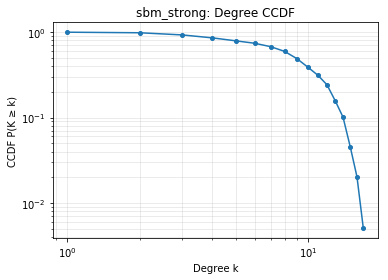

图已保存： C:\Users\86185\network collapse\result\degree_ccdf\sbm_strong_degree_ccdf.png


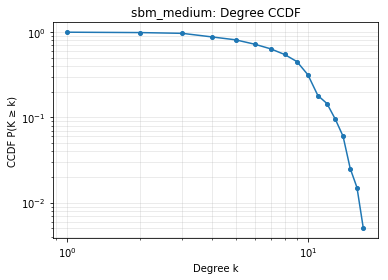

图已保存： C:\Users\86185\network collapse\result\degree_ccdf\sbm_medium_degree_ccdf.png


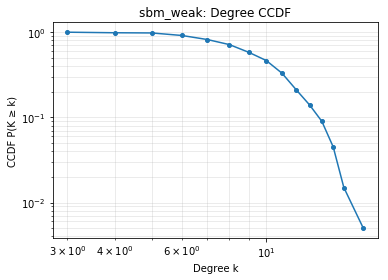

图已保存： C:\Users\86185\network collapse\result\degree_ccdf\sbm_weak_degree_ccdf.png


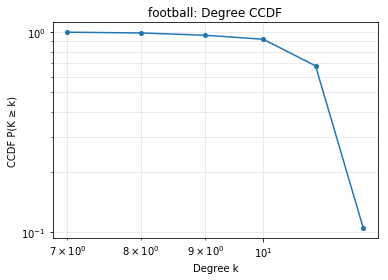

图已保存： C:\Users\86185\network collapse\result\degree_ccdf\football_degree_ccdf.png


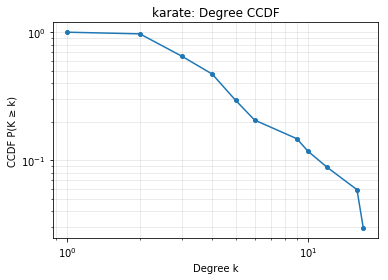

图已保存： C:\Users\86185\network collapse\result\degree_ccdf\karate_degree_ccdf.png


In [5]:
def plot_single_degree_ccdf(G, name, out_dir=CCDF_DIR):
    """
    给单个网络画 degree CCDF 图，并保存。
    """
    x, y = degree_ccdf(G)

    plt.figure(figsize=(5.5, 4))

    plt.loglog(x, y, marker="o", linewidth=1.5, markersize=4)

    plt.xlabel("Degree k")
    plt.ylabel("CCDF P(K ≥ k)")
    plt.title(f"{name}: Degree CCDF")

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    fig_path = out_dir / f"{name}_degree_ccdf.png"
    plt.savefig(fig_path, dpi=250, bbox_inches="tight")
    plt.show()

    print("图已保存：", fig_path)


for name, G in graphs.items():
    plot_single_degree_ccdf(G, name)

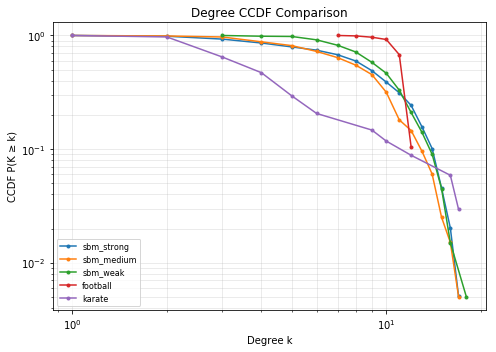

总对比图已保存： C:\Users\86185\network collapse\result\degree_ccdf\all_networks_degree_ccdf.png


In [6]:
plt.figure(figsize=(7, 5))

for name, G in graphs.items():
    x, y = degree_ccdf(G)
    plt.loglog(x, y, marker="o", linewidth=1.5, markersize=3, label=name)

plt.xlabel("Degree k")
plt.ylabel("CCDF P(K ≥ k)")
plt.title("Degree CCDF Comparison")

plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

fig_path = CCDF_DIR / "all_networks_degree_ccdf.png"
plt.savefig(fig_path, dpi=250, bbox_inches="tight")
plt.show()

print("总对比图已保存：", fig_path)

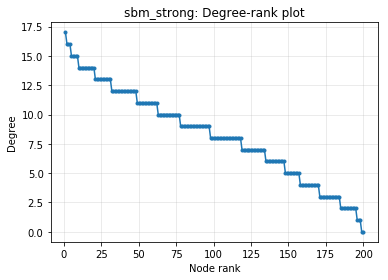

图已保存： C:\Users\86185\network collapse\result\degree_rank\sbm_strong_degree_rank.png


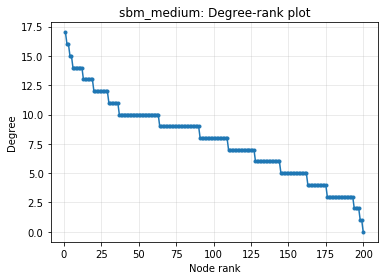

图已保存： C:\Users\86185\network collapse\result\degree_rank\sbm_medium_degree_rank.png


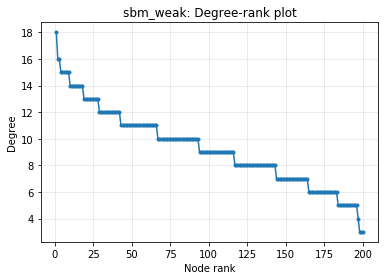

图已保存： C:\Users\86185\network collapse\result\degree_rank\sbm_weak_degree_rank.png


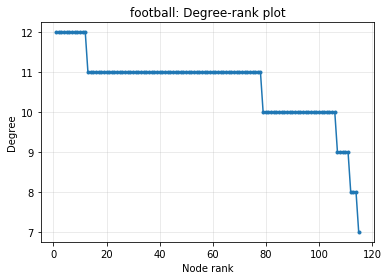

图已保存： C:\Users\86185\network collapse\result\degree_rank\football_degree_rank.png


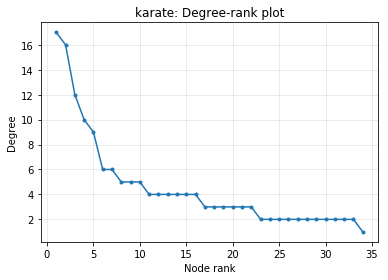

图已保存： C:\Users\86185\network collapse\result\degree_rank\karate_degree_rank.png


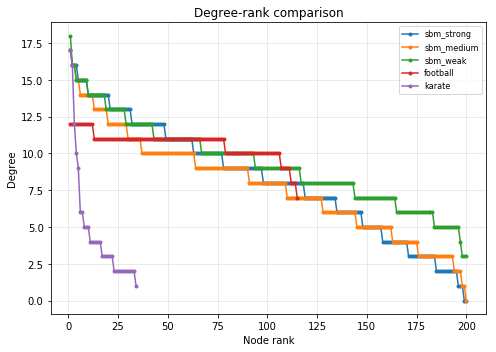

总对比图已保存： C:\Users\86185\network collapse\result\degree_rank\all_networks_degree_rank.png


In [7]:
# =========================
# Degree-rank plot
# 横轴：rank
# 纵轴：degree
# =========================

RANK_DIR = RESULT_DIR / "degree_rank"
RANK_DIR.mkdir(exist_ok=True)

def degree_rank_sequence(G):
    """
    返回按度从大到小排列的 rank 和 degree。
    rank 从 1 开始。
    """
    degrees = sorted([d for _, d in G.degree()], reverse=True)
    ranks = np.arange(1, len(degrees) + 1)
    return ranks, np.array(degrees)


def plot_single_degree_rank(G, name, out_dir=RANK_DIR):
    """
    给单个网络画 degree-rank 图。
    横轴：rank
    纵轴：degree
    """
    ranks, degrees = degree_rank_sequence(G)

    fig, ax = plt.subplots(figsize=(5.5, 4))

    ax.plot(ranks, degrees, marker="o", linewidth=1.5, markersize=3)

    ax.set_xlabel("Node rank")
    ax.set_ylabel("Degree")
    ax.set_title(f"{name}: Degree-rank plot")

    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig_path = out_dir / f"{name}_degree_rank.png"
    fig.savefig(fig_path, dpi=250, bbox_inches="tight")
    plt.show()

    print("图已保存：", fig_path)


# 分别画 5 张 degree-rank 图
for name, G in graphs.items():
    plot_single_degree_rank(G, name)


# 再画一张总对比图
fig, ax = plt.subplots(figsize=(7, 5))

for name, G in graphs.items():
    ranks, degrees = degree_rank_sequence(G)
    ax.plot(ranks, degrees, marker="o", linewidth=1.5, markersize=3, label=name)

ax.set_xlabel("Node rank")
ax.set_ylabel("Degree")
ax.set_title("Degree-rank comparison")

ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()

fig_path = RANK_DIR / "all_networks_degree_rank.png"
fig.savefig(fig_path, dpi=250, bbox_inches="tight")
plt.show()

print("总对比图已保存：", fig_path)

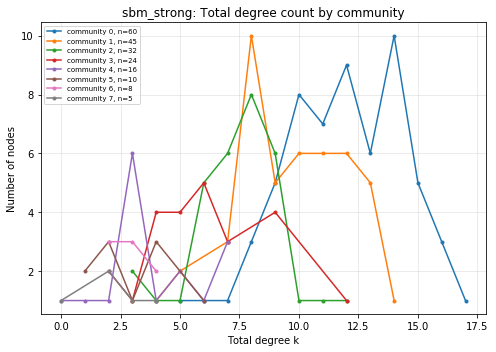

图已保存： C:\Users\86185\network collapse\result\community_total_degree_count\sbm_strong_community_total_degree_count.png
数据已保存： C:\Users\86185\network collapse\result\community_total_degree_count\sbm_strong_community_total_degree_count.csv


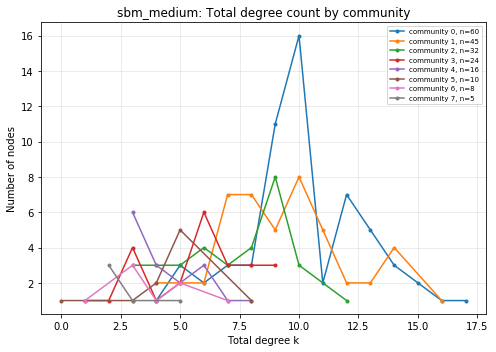

图已保存： C:\Users\86185\network collapse\result\community_total_degree_count\sbm_medium_community_total_degree_count.png
数据已保存： C:\Users\86185\network collapse\result\community_total_degree_count\sbm_medium_community_total_degree_count.csv


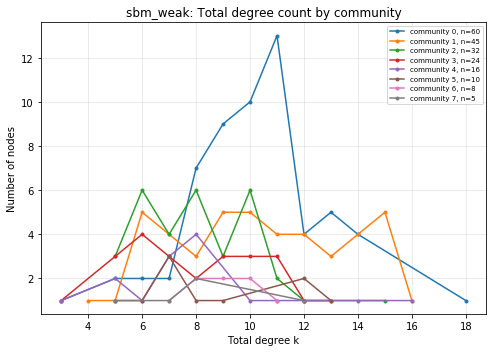

图已保存： C:\Users\86185\network collapse\result\community_total_degree_count\sbm_weak_community_total_degree_count.png
数据已保存： C:\Users\86185\network collapse\result\community_total_degree_count\sbm_weak_community_total_degree_count.csv
三个 SBM 网络的社区总度数量分布图已全部完成。


In [9]:
# =========================
# SBM 每个社区的总度分布：纵轴为节点数量
# total degree = 社区内部边 + 跨社区边
# 每张图对应一个 SBM 网络
# 每条线对应一个社区
# =========================

COMMUNITY_TOTAL_DEGREE_COUNT_DIR = RESULT_DIR / "community_total_degree_count"
COMMUNITY_TOTAL_DEGREE_COUNT_DIR.mkdir(exist_ok=True)

SBM_NAMES = ["sbm_strong", "sbm_medium", "sbm_weak"]


def node_sort_key(node):
    """
    尽量按节点编号排序。
    兼容 node 是 int 或 str 的情况。
    """
    try:
        return int(node)
    except Exception:
        return str(node)


def get_sbm_community_nodes(G, sizes=COMMUNITY_SIZES):
    """
    返回 SBM 每个社区对应的节点列表。

    优先使用节点属性 block；
    如果读取 gml 时 block 属性丢了，
    就按照 COMMUNITY_SIZES 和节点编号顺序重建社区。
    """
    nodes = list(G.nodes())

    has_block = all("block" in G.nodes[n] for n in nodes)

    if has_block:
        comm_dict = {}
        for n in nodes:
            cid = int(G.nodes[n]["block"])
            comm_dict.setdefault(cid, []).append(n)

        return {
            cid: sorted(comm_nodes, key=node_sort_key)
            for cid, comm_nodes in sorted(comm_dict.items())
        }

    sorted_nodes = sorted(nodes, key=node_sort_key)

    comm_dict = {}
    start = 0

    for cid, size in enumerate(sizes):
        comm_dict[cid] = sorted_nodes[start:start + size]
        start += size

    return comm_dict


def community_total_degree_count_distribution(G, community_nodes):
    """
    计算某个社区内节点的总度分布。

    注意：
    这里的度是 total degree，
    包括社区内部边和跨社区边。

    返回：
    unique_degrees: 不同度值
    counts: 每个度值对应的节点数量
    """
    degrees = np.array([G.degree(n) for n in community_nodes], dtype=int)

    if len(degrees) == 0:
        return np.array([]), np.array([])

    unique_degrees, counts = np.unique(degrees, return_counts=True)

    return unique_degrees, counts


def plot_sbm_community_total_degree_count_distribution(
    G,
    name,
    out_dir=COMMUNITY_TOTAL_DEGREE_COUNT_DIR
):
    """
    对一个 SBM 网络画每个社区的总度分布。
    纵轴是数量 count，不是概率。
    """
    community_nodes_dict = get_sbm_community_nodes(G)

    fig, ax = plt.subplots(figsize=(7, 5))

    rows = []

    for cid, comm_nodes in community_nodes_dict.items():
        x, counts = community_total_degree_count_distribution(G, comm_nodes)

        if len(x) == 0:
            continue

        ax.plot(
            x,
            counts,
            marker="o",
            linewidth=1.5,
            markersize=3,
            label=f"community {cid}, n={len(comm_nodes)}"
        )

        for degree_value, count_value in zip(x, counts):
            rows.append({
                "network": name,
                "community": cid,
                "community_size": len(comm_nodes),
                "total_degree": int(degree_value),
                "count": int(count_value),
            })

    ax.set_xlabel("Total degree k")
    ax.set_ylabel("Number of nodes")
    ax.set_title(f"{name}: Total degree count by community")

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)
    fig.tight_layout()

    fig_path = out_dir / f"{name}_community_total_degree_count.png"
    fig.savefig(fig_path, dpi=250, bbox_inches="tight")
    plt.show()

    csv_path = out_dir / f"{name}_community_total_degree_count.csv"

    import csv
    with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
        fieldnames = [
            "network",
            "community",
            "community_size",
            "total_degree",
            "count",
        ]
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print("图已保存：", fig_path)
    print("数据已保存：", csv_path)


for name in SBM_NAMES:
    plot_sbm_community_total_degree_count_distribution(graphs[name], name)

print("三个 SBM 网络的社区总度数量分布图已全部完成。")